<a href="https://colab.research.google.com/github/pedrosampaiom2007-gif/Machine-Learning/blob/main/AULA_06_ML_e_Energia_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Exercício

Treinar um modelo preditivo de classificação da estabilidade de uma rede elétrica.

fonte:

###Preparação do ambiente

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
# Algoritmos do sklearn para classificação
from sklearn.linear_model import LogisticRegression # Prever número regressao
from sklearn.tree import DecisionTreeClassifier # Prever classificação

# Separação dos dados de treino e teste

from sklearn.model_selection import train_test_split

#X_train,X_test,y_train,Y_test

# treinar modelo usa o fit (X_train, Y_train)

# Métricas para classificação

from sklearn.metrics import accuracy_score # acurácia
from sklearn.metrics import confusion_matrix # identificação de onde o modelo errou
from sklearn.metrics import classification_report #Resumo de métricas

###Carregar os dados e gerar um DataFrame

In [5]:
dados= pd.read_csv("https://raw.githubusercontent.com/pedrosampaiom2007-gif/Machine-Learning/refs/heads/main/Data_for_UCI_named.csv")

In [6]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Análise exploratória

In [7]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [8]:
#somente os dados estatisticos numericos
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [10]:
# SOmente caracterisitca de atributo categorico
dados.describe(include="object")


,stabf
count,10000
unique,2
top,unstable
freq,6380


In [9]:
dados["stabf"].unique()

array(['unstable', 'stable'], dtype=object)

In [ ]:
#checagem da quantidade de valores de cada classe da coluna alvo(stabf)
dados["stabf"].value_counts()

## Separação de dados:
entrada(features)------> x
saida(target) --------->y

In [12]:
 #features
 x = dados.drop(["stab","stabf"],axis=1)
x.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [13]:
# Variável alvo (target)
y = dados["stabf"]
y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [15]:
# renomeando classes da coluna alvo
y.map({"stable":"estável","unstable":"instável"})

,stabf
0,instável
1,estável
2,instável
3,instável
4,instável
...,...
9995,instável
9996,estável
9997,estável
9998,instável


## Separação de dados de treino e teste

In [21]:
# x_train,x_test, y_train,y_test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)
# amostra estratificada(balanceamento de classes)
# x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1,stratify=y)

## Treinamento e Geração das previsões do modelo

In [23]:
# instanciando o modelo
modelo_lr=LogisticRegression()


In [24]:
# treinando o modelo
modelo_lr.fit(x_train,y_train)

LogisticRegression()

In [25]:
# Gerando as previsões
y_predict = modelo_lr.predict(x_test)

## Avaliação do modelo

In [29]:
# Acurácia
acuracia= accuracy_score(y_test,y_predict)
print(f"Acurácia do modelo em Regressão Logística: {acuracia*100:.2f}%")

Acurácia do modelo em Regressão Logística: 80.40%


In [30]:
x.shape, # tamanho total dos dados
x_train.shape,# amostra de treino
x_test.shape # amostra de teste

(2000, 12)

In [ ]:
# Matriz de confusão

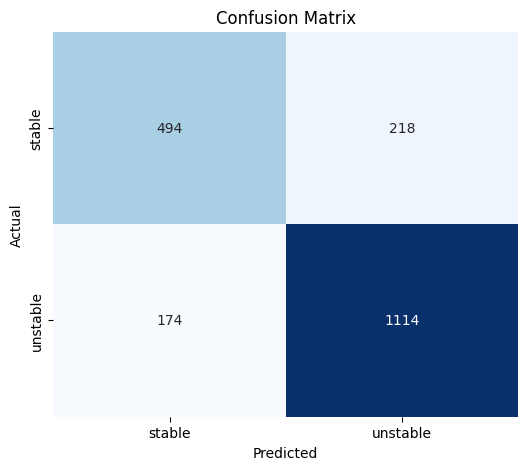

In [31]:
cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['stable', 'unstable'], yticklabels=['stable', 'unstable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [34]:
report = classification_report(y_test, y_predict)
print(report)


              precision    recall  f1-score   support

      stable       0.74      0.69      0.72       712
    unstable       0.84      0.86      0.85      1288

    accuracy                           0.80      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.80      0.80      0.80      2000

